# Week 4 Day 1 Lab


Generally useful functions:
```python
df.head()
df.tail()
df.info()
df.describe()
df.shape
df.columns
df.isnull().sum()
df.duplicated().sum()
df.corr(numeric_only=True)
df.value_counts()
```

Useful plotting functions:

```python
plt.hist()
plt.scatter()
plt.bar()
plt.boxplot()
df.plot()
```

where `df` is a `pandas.DataFrame` object and `plt` is the `matplotlib.pyplot` library


### Problem 1: Data Selection

Choose **one** of the following datasets on GitHub:
- Iris Dataset
- Titanic Dataset


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# I chose Iris

### Problem 2: Loading the Data
1. Load the dataset into a Pandas DataFrame.
2. Display the first five rows.
3. Display the last five rows.

In [3]:
iris_df = pd.read_csv("iris.csv")
print(iris_df.head())
print(iris_df.tail())

   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa
     sepal.length  sepal.width  petal.length  petal.width    variety
145           6.7          3.0           5.2          2.3  Virginica
146           6.3          2.5           5.0          1.9  Virginica
147           6.5          3.0           5.2          2.0  Virginica
148           6.2          3.4           5.4          2.3  Virginica
149           5.9          3.0           5.1          1.8  Virginica


### Problem 3: Inspect Data
1. How many rows are in the dataset?
2. How many columns are in the dataset?
3. What are the column names?
4. What data type is each column?
5. Are there any missing values?
6. Are there any duplicate rows?

In [4]:
# 1. Number of rows
print("Rows:", iris_df.shape[0])

# 2. Number of columns
print("Columns:", iris_df.shape[1])

# 3. Column names
print("Column names:")
print(iris_df.columns.tolist())

# 4. Data type of each column
print("\nData types:")
print(iris_df.dtypes)

# 5. Missing values
print("\nMissing values:")
print(iris_df.isnull().sum())

# 6. Duplicate rows
print("\nDuplicate rows:", iris_df.duplicated().sum())

Rows: 150
Columns: 5
Column names:
['sepal.length', 'sepal.width', 'petal.length', 'petal.width', 'variety']

Data types:
sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety          object
dtype: object

Missing values:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

Duplicate rows: 1


### Problem 4: Summary Statistics
For each numerical column, compute the following:
- Mean
- Median
- Mode
- Minimum
- Maximum
- Standard deviation


1. Which variable has the greatest variation?
2. Which variable has the smallest variation?


In [5]:

numeric_df = iris_df.select_dtypes(include="number")

summary = pd.DataFrame({
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Mode": numeric_df.mode().iloc[0],
    "Minimum": numeric_df.min(),
    "Maximum": numeric_df.max(),
    "Standard Deviation": numeric_df.std()
})

print(summary)

# 1. petal.length
# 2. sepal.width

                  Mean  Median  Mode  Minimum  Maximum  Standard Deviation
sepal.length  5.843333    5.80   5.0      4.3      7.9            0.828066
sepal.width   3.057333    3.00   3.0      2.0      4.4            0.435866
petal.length  3.758000    4.35   1.4      1.0      6.9            1.765298
petal.width   1.199333    1.30   0.2      0.1      2.5            0.762238


### Problem 5: Visualization
1. Choose a numerical column from your dataset and:
    - Plot the corresponding histogram. 
        - What does the distribution look like?
        - Is it symmetric or skewed?
    - Plot the corresponding box plot.
        - Are there any outliers?
        - Explain what you observe.
2. Choose one categorical column from your dataset and:
    - Plot the corresponding bar chart.
        - Which category occurs most frequently?
        - Which occurs least frequently?


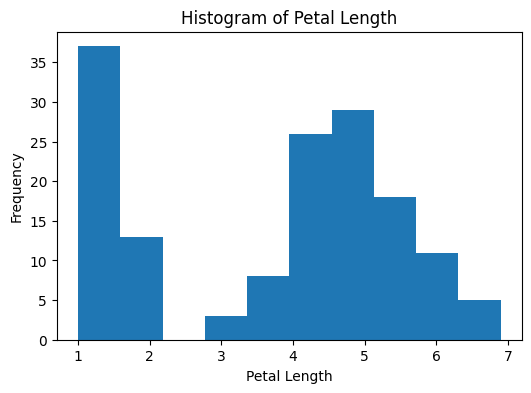

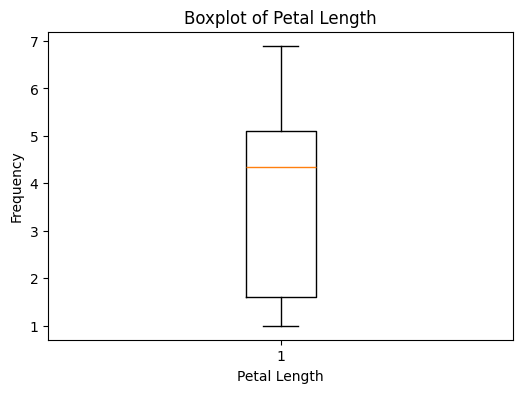

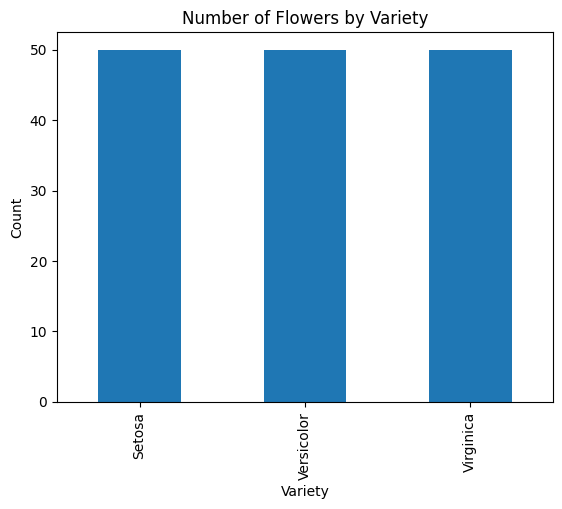

In [8]:
plt.figure(figsize=(6,4))
plt.hist(iris_df["petal.length"], bins=10)
plt.title("Histogram of Petal Length")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")
plt.show()

# 1. Distribution looks bimodal. The distribution isn't symmetric.

plt.figure(figsize=(6,4))
plt.boxplot(iris_df["petal.length"])
plt.title("Boxplot of Petal Length")
plt.xlabel("Petal Length")
plt.ylabel("Frequency")
plt.show()

# 2. No outliers. Median is somewhere between 4 and 5. The box is very big (1.6-5.1) so the dataset has big variability. Whiskers extend from 1 to 6.9

iris_df["variety"].value_counts().plot(kind="bar")

plt.title("Number of Flowers by Variety")
plt.xlabel("Variety")
plt.ylabel("Count")
plt.show()

# 3. All flowers occur in equal amounts.